In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
import get_final_hist_amps as get_hists
utils.load_plotting_setting()

from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation

In [2]:
latitude_newhaven  = 41.31 # deg
longitude_newhaven = -72.923611 # deg

location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven)

In [3]:
amp2kev_sphere_20241202 = 5945.245097647231
amp2kev_sphere_20250103 = 5923.2059527417405

data_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/final_recon_before_bg_rate_cut'
# data_dir = r'/home/yt388/microspheres/dm_nanospheres/data_processed/sphere_data/final_recon_before_bg_rate_cut'
file0 = h5py.File(rf'{data_dir}/sphere_20241202_unbinned_amps.h5py')
file1 = h5py.File(rf'{data_dir}/sphere_20250103_unbinned_amps.h5py')

amps0 = file0['unbinned_amps']['amplitude'][:]
amps1 = file1['unbinned_amps']['amplitude'][:]
time0 = file0['unbinned_amps']['time'][:]
time1 = file1['unbinned_amps']['time'][:]

file0.close()
file1.close()

data_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data'
# data_dir = r'/home/yt388/microspheres/dm_nanospheres/data_processed/sphere_data'
file0 = h5py.File(rf'{data_dir}/sphere_20241202_unbinned_amps_bg.h5py')
file1 = h5py.File(rf'{data_dir}/sphere_20250103_unbinned_amps_bg.h5py')

amps0_bg = file0['unbinned_amps']['amplitude'][:]
amps1_bg = file1['unbinned_amps']['amplitude'][:]
time0_bg = file0['unbinned_amps']['time'][:]
time1_bg = file1['unbinned_amps']['time'][:]

file0.close()
file1.close()

In [4]:
def group_into_sidereal_days(timestamps, hours):
    sday = 86164.091

    idx_day = np.where(np.diff(hours)<0)[0]

    hours_day = []
    for i, idx_end in enumerate(idx_day):
        if i == 0:
            idx_start = 0
        else:
            idx_start = idx_day[i-1]
        
        if (timestamps[idx_start+1] - timestamps[idx_start]) > sday:
            print(timestamps[idx_start+1] - timestamps[idx_start])
            hours_day.append([])
        hours_day.append(hours[idx_start+1:idx_end+1])

    # Add the final day
    hours_day.append(hours[idx_end+1:])

    return hours_day

In [5]:
# Get the timestamps of local sidereal time bins
def get_sidereal_bins(t0, lst_hour0, ndays):
    sday = 86164.0905

    begin = t0 - (lst_hour0 / 24) * sday
    bins_sidereal_timestamps = []
    for i in range(24 * ndays + 1):
        bins_sidereal_timestamps.append(begin + i * sday/24)

    t_bins = Time(bins_sidereal_timestamps, format='unix', scale='utc')
    lst_bins = t_bins.sidereal_time('apparent', longitude=location.lon).hour
    correction = (np.round(lst_bins) - lst_bins) * (sday/(24*3600))

    return np.asarray(bins_sidereal_timestamps) + correction

In [6]:
bins_sidereal_0 = get_sidereal_bins(time0[0], Time(time0[0], format='unix', scale='utc').sidereal_time('apparent', longitude=location.lon).hour, 17)
bins_sidereal_1 = get_sidereal_bins(time1[0], Time(time1[0], format='unix', scale='utc').sidereal_time('apparent', longitude=location.lon).hour, 22)

In [7]:
thr_kev = 1500

hh_0, be = np.histogram(time0_bg[np.abs(amps0_bg)*amp2kev_sphere_20241202 > thr_kev], bins=bins_sidereal_0)
hh_1, be = np.histogram(time1_bg[np.abs(amps1_bg)*amp2kev_sphere_20250103 > thr_kev], bins=bins_sidereal_1)

hist_day_sidereal_0 = np.reshape(hh_0, (17, 24))
hist_day_sidereal_1 = np.reshape(hh_1, (22, 24))

In [8]:
# Read in the effective livetime (# of windows) for each day
# after livetime selection (but without applying background cut)
npz_livetime = np.load('livetime_windows_day_before_bg_cut.npz')

livetime_sidereal_0 = npz_livetime['sidereal_0']
livetime_sidereal_1 = npz_livetime['sidereal_1']

npz_livetime.close()

In [9]:
# Now need to correct for live time due to background cut
t_cut_end_actual_0 = 1734462007.9319303

t_cut_start_actual_1 = 1736082054.1595662
t_cut_end_actual_1 = 1737774005.3052022

In [10]:
def get_livetime_correction(livetime_sidereal, bins_sidereal, t_cut_start=None, t_cut_end=None):
    ret = np.ones(livetime_sidereal.size)

    if t_cut_start is not None:
        idx_bin_start = np.where(bins_sidereal < t_cut_start)[0][-1]
        ret[0:idx_bin_start] = 0
        ret[idx_bin_start] = (bins_sidereal[idx_bin_start+1] - t_cut_start) / (bins_sidereal[idx_bin_start+1] - bins_sidereal[idx_bin_start])

    if t_cut_end is not None:
        idx_bin_end = np.where(bins_sidereal > t_cut_end)[0][0]
        ret[idx_bin_end:] = 0
        ret[idx_bin_end - 1] = (t_cut_end - bins_sidereal[idx_bin_end-1]) / (bins_sidereal[idx_bin_end] - bins_sidereal[idx_bin_end - 1])

    return np.reshape(ret, livetime_sidereal.shape)


In [11]:
livetime_corr_0 = get_livetime_correction(livetime_sidereal_0, bins_sidereal_0, None, t_cut_end_actual_0)
livetime_corr_1 = get_livetime_correction(livetime_sidereal_1, bins_sidereal_1, t_cut_start_actual_1, t_cut_end_actual_1)

livetime_sidereal_0_actual = livetime_sidereal_0 * livetime_corr_0
livetime_sidereal_1_actual = livetime_sidereal_1 * livetime_corr_1

In [12]:
np.sum(livetime_sidereal_1_actual) * 10e-3 / 3600 / 24

15.84691252079441

In [13]:
def get_mean_rate(hist_day, livetime_day, hour_per_bin=1):
    hist_sum = np.empty(hist_day.shape[1])
    livetime_sum  = np.empty(hist_day.shape[1])

    livetime_day_hour = livetime_day * 10e-3 / 3600

    hist_bin = hist_day.T
    livetime_hour_bin = livetime_day_hour.T
    for i, bin in enumerate(hist_bin):
        good_bin_idx = livetime_hour_bin[i] > 0

        hist_sum[i] = np.sum(bin[good_bin_idx])
        livetime_sum[i] = np.sum(livetime_hour_bin[i][good_bin_idx])

    n_rate = int(hist_day.shape[1] / hour_per_bin)
    mean_rate, err_rate = np.empty(n_rate), np.empty(n_rate)

    for i in range(n_rate):
        n_events = np.sum(hist_sum[i*hour_per_bin:(i*hour_per_bin + hour_per_bin)])
        livetime = np.sum(livetime_sum[i*hour_per_bin:(i*hour_per_bin + hour_per_bin)])
        mean_rate[i] = n_events / livetime
        err_rate[i] = np.sqrt(n_events) / livetime

    return mean_rate, err_rate

In [14]:
mean_sidereal_0, err_sidereal_0 = get_mean_rate(hist_day_sidereal_0, livetime_sidereal_0_actual, hour_per_bin=2)
mean_sidereal_1, err_sidereal_1 = get_mean_rate(hist_day_sidereal_1, livetime_sidereal_1_actual, hour_per_bin=2)

avg_rate_sidereal_1 = np.sum(hist_day_sidereal_1)/(np.sum(livetime_sidereal_1_actual)*10e-3/3600)

In [15]:
rate_all_1 = hist_day_sidereal_1 / (livetime_sidereal_1_actual * 10e-3 / 3600)

/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_11246/2876708158.py:1: RuntimeWarning: invalid value encountered in divide
  rate_all_1 = hist_day_sidereal_1 / (livetime_sidereal_1_actual * 10e-3 / 3600)


In [16]:
np.max(np.nan_to_num(rate_all_1).T, axis=1)

array([3.29139848, 2.21281095, 0.        , 2.2180941 , 3.36635268,
       1.15262703, 2.49568455, 3.55848435, 3.78292988, 2.44426565,
       4.46661207, 4.41071068, 2.15930902, 2.12595077, 1.27599847,
       2.52958206, 4.21345027, 1.29729262, 1.05091386, 4.73331288,
       3.19761245, 2.62125106, 1.4861724 , 1.09128608])

In [17]:
dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed'
# dir = r'/home/yt388/microspheres/dm_nanospheres/data_processed'

npz = np.load(f'{dir}/dm_rate/daily_modulation/hourly_rate.npz')
rates = npz['hourly_rate']
npz.close()

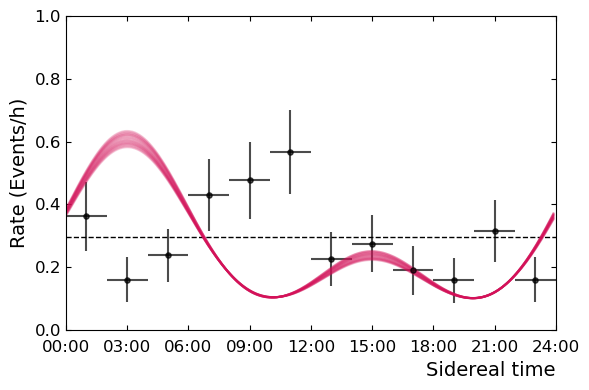

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

bins = np.linspace(0, 24, 13)
bc = 0.5 * (bins[1:] + bins[:-1])

# ax.errorbar(bc, mean_sidereal_0, yerr=err_sidereal_0, xerr=1, fmt='.', color='k', alpha=0.7)
ax.errorbar(bc, mean_sidereal_1, yerr=err_sidereal_1, xerr=1, fmt='.', color='k', alpha=0.7, markersize=7.5)
ax.hlines(y=np.sum(hist_day_sidereal_1)/(np.sum(livetime_sidereal_1_actual)*10e-3/3600), xmin=0, xmax=24, color='k', linestyle='--', linewidth=1)

# Plot the expected DM signal
for i in range(rates.shape[0]):
    ax.plot(np.linspace(0, 24, 200, endpoint=False), rates[i], color='#d41159', alpha=0.2)

ax.set_ylabel('Rate (Events/h)', fontsize=14, x=0.03, y=0.5)
ax.set_xlabel('Time (day)', ha='right', x=1.0, fontsize=14)
ax.set_xlabel('Sidereal time', ha='right', x=1.0, fontsize=14)

def float_to_time(x, pos):
    hour = int(x)
    minute = int((x - hour) * 60)
    return f"{hour:02d}:{minute:02d}"

ax.set_xticks(np.arange(0, 27, 3))  # every 3 hours
ax.tick_params(axis='x', which='major', pad=7.5)
ax.xaxis.set_major_formatter(plt.FuncFormatter(float_to_time))

ax.set_xlim(0, 24)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../paper_plots/daily_modulation.pdf', dpi=600)

#### Perform a likelihood ratio hypothesis testing between flat rate and DM model + flat background

In [71]:
def get_dm_theory_hist(tt, rates, livetiem_twohour, n_hours_bin=2):
    mean_rate = np.mean(rates, axis=0)

    n_bins = int(24/n_hours_bin)
    rate_bins = np.empty(n_bins)
    for i in range(n_bins):
        idx = np.logical_and(tt > i*n_hours_bin, tt < (i+1)*n_hours_bin)
        rate_bins[i] = np.trapz(mean_rate[idx], tt[idx]) / n_hours_bin

    return rate_bins * livetiem_twohour

In [ ]:
livetime_hour_1 = np.sum(livetime_sidereal_1_actual, axis=0)
livetime_twohour_1 = np.sum(np.reshape(livetime_hour_1, (12, 2)), axis=1) * 10e-3 / 3600

hist_hour_1 = np.sum(hist_day_sidereal_1, axis=0)
hist_twohour_1 = np.sum(np.reshape(hist_hour_1, (12, 2)), axis=1)

theory_flat = avg_rate_sidereal_1 * livetime_twohour_1
theory_dm   = get_dm_theory_hist(np.linspace(0, 24, 200, endpoint=False), rates, livetime_twohour_1, 2)

In [94]:
scale_flatbg = np.linspace(0, 2, 50)

theory_flats = []
theory_dm_plus_flat = []
for scale in scale_flatbg:
    theory_dm_plus_flat.append(theory_dm + scale * theory_flat)
    theory_flats.append(scale * theory_flat)
    
nll_dms = np.array([np.sum(_theory_dm_flat - hist_twohour_1 * np.log(_theory_dm_flat)) for _theory_dm_flat in theory_dm_plus_flat])
nll_flats = np.array([np.sum(_theory_flat - hist_twohour_1 * np.log(_theory_flat)) for _theory_flat in theory_flats])
nll_dm = np.min(nll_dms)
nll_flat = np.min(nll_flats)

/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_3156/2521068012.py:10: RuntimeWarning: divide by zero encountered in log
  nll_flats = np.array([np.sum(_theory_flat - hist_twohour_1 * np.log(_theory_flat)) for _theory_flat in theory_flats])


In [107]:
from scipy.special import gamma
def chi2(x, k=1):
    return x**(k/2 - 1) * np.exp(-1*x/2) / (2**(k/2) * gamma(k/2))

two_delta_nll = 2 * (nll_dm - nll_flat)
print(rf'2 \Delta NLL = {two_delta_nll}')
print(rf'\alpha = {chi2(two_delta_nll, 1)}')

2 \Delta NLL = 33.26124481465152
\alpha = 4.143365774268862e-09
